<a href="https://colab.research.google.com/github/Cooljoe67/ML_DSAI/blob/main/6_AgglomerativeClustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AgglomerativeClustering
In this notebook, we'll explore Hierarchical Clustering using the [`AgglomerativeClustering`](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.AgglomerativeClustering.html) algorithm. We'll walk through the process of applying it to a dataset, understanding its parameters, visualising the results, and evaluating the clustering performance.

---
## 1.&nbsp; Import Libraries and Load Data 💾
First, let's import the necessary libraries and load our dataset. We'll be using pandas for data manipulation, scikit-learn for preprocessing and clustering, seaborn for visualisation, and t-SNE for dimensionality reduction.

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage

# Set all SKLearn outputs to pandas DataFrames
from sklearn import set_config
set_config(transform_output="pandas")

In [ ]:
# ID of the Google Sheet for student food preferences
sheet_id = "1gYXqOBLEYIr99YmKGq2nIvK3CJmoWzsvwfwR9adfo2w"

# Title of the Google Sheet
sheet_name = "18136796"

# URL to download the Google Sheet as a CSV
url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv&gid={sheet_name}"

# Create a Pandas DataFrame from the CSV data
foods_df = pd.read_csv(url, index_col="student")

---
## 2.&nbsp; Data Preprocessing 🧹
Before applying Agglomerative Clustering, it's essential to preprocess the data. We'll drop irrelevant columns and scale the features to ensure that each feature contributes equally to the distance calculations.


### 2.1. Drop Irrelevant Columns

In [ ]:
# Drop the 'favorite_color' column as it's not needed for clustering
foods_df = foods_df.drop(columns=['favorite_color'])

### 2.2. Scale the Data
Scaling the data is crucial for distance-based algorithms like Agglomerative Clustering. We'll use `StandardScaler` to standardise the features.

In [ ]:
# Initialise the scaler
scaler = StandardScaler()

# Fit and transform the data
foods_scaled = scaler.fit_transform(foods_df)

---
## 3.&nbsp; Agglomerative Clustering 🔍

### 3.1. Choosing the Number of Clusters
Unlike DBSCAN, Agglomerative Clustering requires specifying the number of clusters (`n_clusters`) beforehand. We'll use the dendrogram to help determine an appropriate number of clusters.

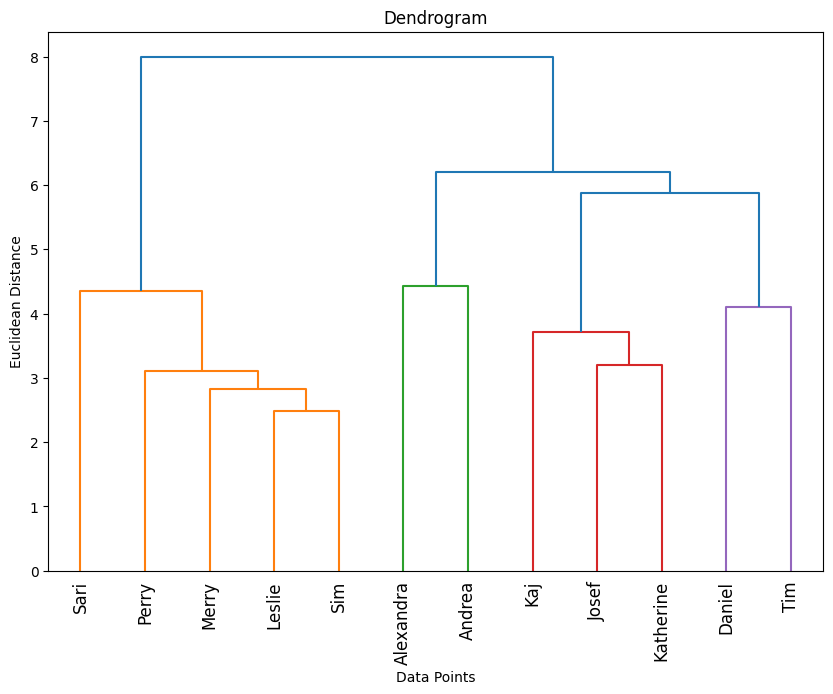

In [ ]:
# Perform WARD agglomerative clustering using scipy to plot dendrogram
linked = linkage(foods_scaled, method='ward')

plt.figure(figsize=(10, 7))
dendrogram(linked,
           orientation='top',
           labels=foods_scaled.index,
           distance_sort=True,
           show_leaf_counts=False)
plt.title('Dendrogram')
plt.xlabel('Data Points')
plt.xticks(rotation=90)
plt.ylabel('Euclidean Distance')
plt.show()

**Interpreting the Dendrogram:**
  - Look for the largest vertical distance without any horizontal line crossing it. This "elbow" point suggests a suitable number of clusters.
  - For example, if the largest gap is between 2 and 3 clusters, you might choose 2 or 3 clusters.
  - From the dendrogram above, how many clusters would you choose?

###3.2. Simplifying a Complex Dendrogram

If your dendrogram becomes too intricate to interpret effectively, consider employing the two techniques we've previously covered: the **elbow method** and the **silhouette score**. While adapting the code is up to you, here are some tips to guide you:

- **Experiment with Different Metrics:** Try various distance metrics (e.g., Euclidean, Manhattan, or cosine) to see how they affect the clustering results.
- **Adjust Linkage Methods:** Explore different linkage criteria to determine which provides the most meaningful clusters for your data.

By tweaking these parameters, you can achieve clearer and more interpretable clustering outcomes.

> **Remember**: The results from the elbow and silhouette methods are merely guidelines. Use them as starting points for your experimentation, but ultimately, the most important metric is how closely the clusters align with your business goals.

### 3.3.&nbsp; Applying Agglomerative Clustering
With the parameters estimated, we'll proceed to apply `AgglomerativeClustering` to our dataset.

In [ ]:
# Define the number of clusters based on the dendrogram
n_clusters = 4

# Initialise AgglomerativeClustering with chosen parameters
agg_clustering = AgglomerativeClustering(n_clusters=n_clusters,
                                         metric='euclidean',
                                         linkage='ward')

# Fit the model and predict cluster labels
clusters = agg_clustering.fit(foods_scaled)

# Add the cluster labels to the DataFrame
foods_scaled['Cluster'] = clusters.labels_

# Display the cluster assignments
foods_scaled[['Cluster']]

,Cluster
student,
Alexandra,0
Andrea,0
Daniel,2
Josef,3
Kaj,3
Katherine,3
Leslie,1
Merry,1
Perry,1


---
## 4.&nbsp; Visualise Clusters using t-SNE 📊
To visualise the clusters, especially in high-dimensional data, we'll use t-SNE to reduce the data to two dimensions.

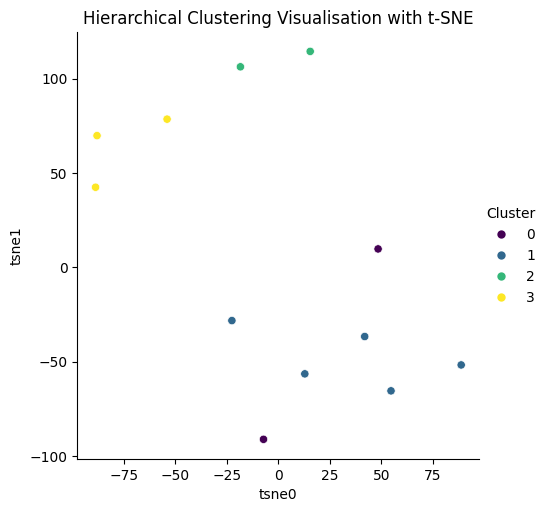

In [ ]:
# Initialise t-SNE with 2 components
tsne = TSNE(n_components=2,
            random_state=42,
            perplexity=3)

# Fit and transform the scaled data (excluding the Cluster column)
tsne_components = tsne.fit_transform(foods_scaled.drop('Cluster', axis=1))

# Add the Cluster labels to the t-SNE DataFrame
tsne_components['Cluster'] = foods_scaled['Cluster']

(
sns.relplot(data = tsne_components,
            x = 'tsne0',
            y = 'tsne1',
            hue = 'Cluster',
            palette = 'viridis')
.set(title = "Hierarchical Clustering Visualisation with t-SNE")
);

* From the t-SNE plot, what impression do you get of the initial clusters?
* Do these look like well-defined clusters?
* If anything, what would you change to improve the clustering?

---
## 5.&nbsp; A Reminder of the Agglomerative Clustering Parameters 🧠
Understanding how the parameters affect Agglomerative Clustering's performance is crucial for effective clustering.

### 5.1. Number of Clusters (`n_clusters`)
**Definition**: The number of clusters to find in the data.

**Impact**:
* **Too Few Clusters**: Distinct groups may be merged, leading to loss of meaningful information.
* **Too Many Clusters**: Similar groups may be split, resulting in fragmented clusters.

### 5.2. Linkage Criteria (`linkage`)
**Definition**: Determines how the decide which clusters should be merged.

**Impact**:
* **ward**: Tends to create compact, spherical clusters.
* **complete**: Can capture clusters with complex shapes but may be sensitive to noise.
* **average**: Provides a balance between ward and complete.

### 5.3. Metric (`metric`)
**Definition**: Metric used to compute the linkage.

**Impact**:
* **Euclidean**: Suitable for most cases where distance is meaningful.
* **Manhattan**: Useful when the dataset has high-dimensional data.
* **Cosine**: Good for text data or when direction is more important than magnitude.

---
## 6.&nbsp; Challenge: Apply This to the Spotify Dataset 🎵
1. **Parameter Tuning**:
    * Experiment with different numbers of clusters and linkage criteria.
    * Observe how these changes affect the clustering results and the Silhouette Score.
    * Identify the parameter combination that yields the highest Silhouette Score.
2. **Dendrogram Analysis**:
    * Analyse the dendrogram to decide on the optimal number of clusters.
    * Compare your decision with the Silhouette Score findings.
3. **Comparison with DBSCAN**:
    * Compare the clustering results with those obtained from DBSCAN.
    * Discuss the advantages and disadvantages of each method based on your observations.
4. **Interpretation of Clusters**:
    * Analyse the characteristics of each cluster.
    * Discuss any patterns or insights derived from the clustering.